# AI药物设计第3次课 - Python实践教程
## 从房价预测到分子性质预测
### 0. 环境准备

In [1]:
# 安装必要的包（如果还没有安装）
# !pip install rdkit
# !pip install pandas numpy matplotlib seaborn scikit-learn

# 导入所有需要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings

# 忽略RDKit的警告信息
warnings.filterwarnings('ignore', message='to-Python converter')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

# RDKit相关导入
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams
from rdkit.Chem import Lipinski

print("✅ 所有库导入成功！")

✅ 所有库导入成功！


### 第一部分：线性回归基础 - 房价预测
#### 1.1 准备房价数据

In [2]:
# 创建房价数据集
area = np.array([50, 65, 80, 95, 110, 45, 75, 88, 102, 120])  # 面积(㎡)
price = np.array([150, 180, 220, 250, 290, 140, 200, 240, 275, 310])  # 价格(万元)

# 创建DataFrame便于查看
house_data = pd.DataFrame({
    '房子编号': range(1, 11),
    '面积(㎡)': area,
    '价格(万元)': price
})

print("📊 房价数据集：")
print(house_data)

📊 房价数据集：
   房子编号  面积(㎡)  价格(万元)
0     1     50     150
1     2     65     180
2     3     80     220
3     4     95     250
4     5    110     290
5     6     45     140
6     7     75     200
7     8     88     240
8     9    102     275
9    10    120     310


#### 1.2 数据可视化

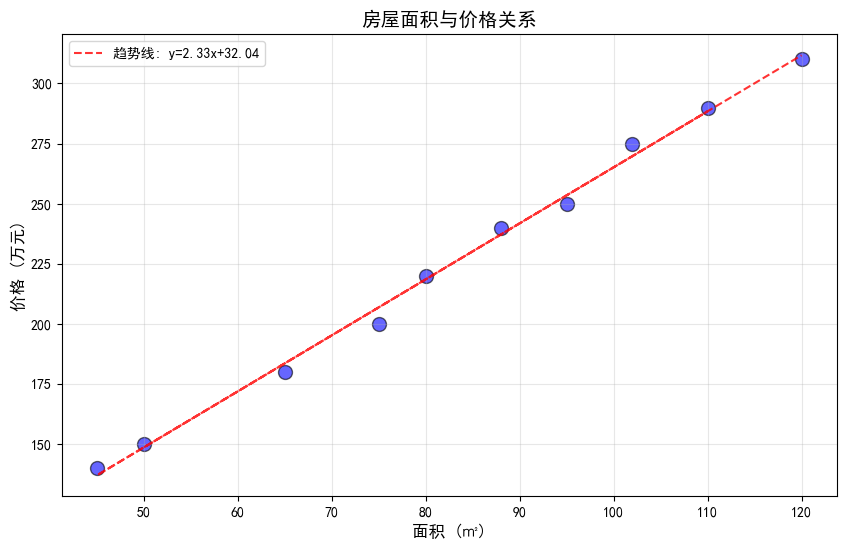

📈 观察发现：面积和价格呈现明显的线性关系！


In [3]:
# 绘制散点图观察规律
plt.figure(figsize=(10, 6))
plt.scatter(area, price, s=100, alpha=0.6, c='blue', edgecolors='black')
plt.xlabel('面积 (㎡)', fontsize=12)
plt.ylabel('价格 (万元)', fontsize=12)
plt.title('房屋面积与价格关系', fontsize=14)
plt.grid(True, alpha=0.3)

# 添加趋势线
z = np.polyfit(area, price, 1)
p = np.poly1d(z)
plt.plot(area, p(area), "r--", alpha=0.8, label=f'趋势线: y={z[0]:.2f}x+{z[1]:.2f}')
plt.legend()
plt.show()

print(f"📈 观察发现：面积和价格呈现明显的线性关系！")

#### 1.3 使用scikit-learn进行线性回归

In [4]:
# 准备数据 - reshape为scikit-learn需要的格式
X = area.reshape(-1, 1)  # 特征需要是2D数组
y = price  # 目标值

# 创建并训练线性回归模型
model = LinearRegression()
model.fit(X, y)

# 获取模型参数
w = model.coef_[0]  # 斜率（每㎡价格）
b = model.intercept_  # 截距（基础价格）

print(f"🏠 房价预测公式：房价 = {w:.2f} × 面积 + {b:.2f}")
print(f"   - 斜率w = {w:.2f} 万元/㎡（每平米单价）")
print(f"   - 截距b = {b:.2f} 万元（基础价格）")

🏠 房价预测公式：房价 = 2.33 × 面积 + 32.04
   - 斜率w = 2.33 万元/㎡（每平米单价）
   - 截距b = 32.04 万元（基础价格）


#### 1.4 预测新房价

In [5]:
# 预测85㎡房子的价格
area_to_predict = 85
predicted_price = model.predict([[area_to_predict]])[0]

print(f"\n🎯 预测结果：")
print(f"   85㎡的房子预测价格：{predicted_price:.1f}万元")

# 批量预测
test_areas = [60, 90, 130]
print(f"\n📊 批量预测：")
for test_area in test_areas:
    pred = model.predict([[test_area]])[0]
    print(f"   {test_area}㎡ → {pred:.1f}万元")


🎯 预测结果：
   85㎡的房子预测价格：230.2万元

📊 批量预测：
   60㎡ → 171.9万元
   90㎡ → 241.8万元
   130㎡ → 335.1万元


#### 1.5 模型评估


📈 模型性能评估：
   R² 分数: 0.9958 （越接近1越好）
   均方误差 MSE: 12.60
   均方根误差 RMSE: 3.55 万元


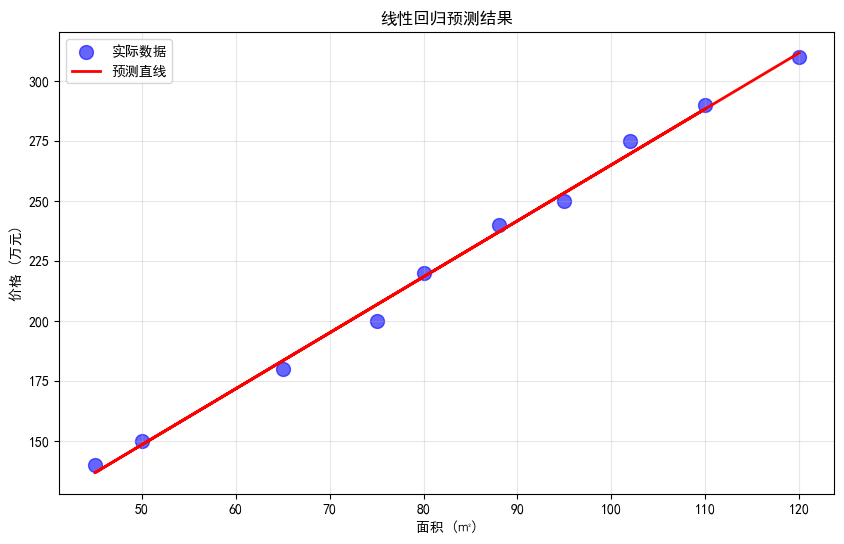

In [6]:
# 计算模型在训练数据上的表现
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"\n📈 模型性能评估：")
print(f"   R² 分数: {r2:.4f} （越接近1越好）")
print(f"   均方误差 MSE: {mse:.2f}")
print(f"   均方根误差 RMSE: {rmse:.2f} 万元")

# 可视化预测结果
plt.figure(figsize=(10, 6))
plt.scatter(area, price, s=100, alpha=0.6, label='实际数据', c='blue')
plt.plot(area, y_pred, 'r-', linewidth=2, label='预测直线')
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (万元)')
plt.title('线性回归预测结果')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 第二部分：RDKit基础 - 分子的数字化表示
#### 2.1 创建分子对象

In [7]:
# 从SMILES创建分子对象
print("🧪 创建分子对象：")

# 阿司匹林
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
aspirin = Chem.MolFromSmiles(aspirin_smiles)
print(f"✅ 阿司匹林分子对象创建成功: {aspirin}")

# 咖啡因
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
caffeine = Chem.MolFromSmiles(caffeine_smiles)
print(f"✅ 咖啡因分子对象创建成功: {caffeine}")

# 对乙酰氨基酚（扑热息痛）
paracetamol_smiles = "CC(=O)Nc1ccc(O)cc1"
paracetamol = Chem.MolFromSmiles(paracetamol_smiles)
print(f"✅ 对乙酰氨基酚分子对象创建成功: {paracetamol}")

🧪 创建分子对象：
✅ 阿司匹林分子对象创建成功: <rdkit.Chem.rdchem.Mol object at 0x00000287A8B3D850>
✅ 咖啡因分子对象创建成功: <rdkit.Chem.rdchem.Mol object at 0x00000287A8B3D8C0>
✅ 对乙酰氨基酚分子对象创建成功: <rdkit.Chem.rdchem.Mol object at 0x00000287A8B3D3F0>


#### 2.2 分子可视化


🎨 分子结构可视化：


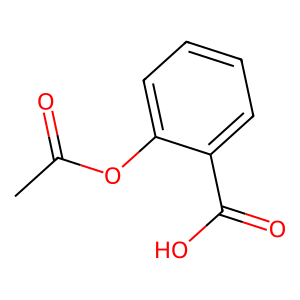

In [8]:
# 单个分子可视化
print("\n🎨 分子结构可视化：")

# 显示阿司匹林
img_aspirin = Draw.MolToImage(aspirin, size=(300, 300))
img_aspirin

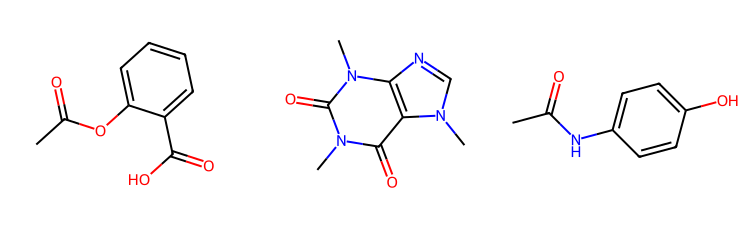

In [9]:
# 批量分子可视化对比
molecules = [aspirin, caffeine, paracetamol]
legends = ['阿司匹林', '咖啡因', '对乙酰氨基酚']

# 生成网格图
img_grid = Draw.MolsToGridImage(
    molecules, 
    molsPerRow=3, 
    subImgSize=(250, 250), 
    legends=legends,
    returnPNG=False
)
img_grid

#### 2.3 获取分子基本信息

In [10]:
# 分子基本信息提取
print("📊 阿司匹林分子基本信息：")

# 原子和键的统计
num_atoms = aspirin.GetNumAtoms()
num_bonds = aspirin.GetNumBonds()
num_rings = aspirin.GetRingInfo().NumRings()

print(f"   原子数: {num_atoms}")
print(f"   键数: {num_bonds}")
print(f"   环数: {num_rings}")

# 获取分子式
formula = rdMolDescriptors.CalcMolFormula(aspirin)
print(f"   分子式: {formula}")

# 获取精确分子量
exact_mass = rdMolDescriptors.CalcExactMolWt(aspirin)
print(f"   精确分子量: {exact_mass:.2f}")

📊 阿司匹林分子基本信息：
   原子数: 13
   键数: 13
   环数: 1
   分子式: C9H8O4
   精确分子量: 180.04


#### 2.4 氢原子处理

In [11]:
# 氢原子的添加和移除
print("\n⚛️ 氢原子处理演示：")

# 创建乙醇分子
ethanol = Chem.MolFromSmiles("CCO")
print(f"隐式氢原子数: {ethanol.GetNumAtoms()} 个")

# 添加显式氢原子
ethanol_with_h = Chem.AddHs(ethanol)
print(f"显式氢原子数: {ethanol_with_h.GetNumAtoms()} 个")

# 移除氢原子
ethanol_no_h = Chem.RemoveHs(ethanol_with_h)
print(f"移除后原子数: {ethanol_no_h.GetNumAtoms()} 个")


⚛️ 氢原子处理演示：
隐式氢原子数: 3 个
显式氢原子数: 9 个
移除后原子数: 3 个


### 第三部分：分子描述符计算
#### 3.1 计算单个分子的描述符

In [12]:
# 计算阿司匹林的各种描述符
print("📊 阿司匹林分子描述符计算：")
print("="*50)

# 物理化学性质描述符
mw = Descriptors.MolWt(aspirin)  # 分子量
logp = Descriptors.MolLogP(aspirin)  # 脂水分配系数
tpsa = Descriptors.TPSA(aspirin)  # 极性表面积
hbd = Descriptors.NumHDonors(aspirin)  # 氢键供体数
hba = Descriptors.NumHAcceptors(aspirin)  # 氢键受体数

print(f"🏷️  分子量: {mw:.2f} g/mol")
print(f"🫧 LogP (脂溶性): {logp:.2f}")
print(f"⚡ TPSA (极性表面积): {tpsa:.2f} Ų")
print(f"🔗 氢键供体数: {hbd}")
print(f"🔗 氢键受体数: {hba}")

# 结构特征描述符
heavy_atoms = Descriptors.HeavyAtomCount(aspirin)
rotatable_bonds = Descriptors.NumRotatableBonds(aspirin)
aromatic_rings = Descriptors.NumAromaticRings(aspirin)
saturated_rings = Descriptors.NumSaturatedRings(aspirin)

print(f"\n⚛️  重原子数: {heavy_atoms}")
print(f"🔄 可旋转键数: {rotatable_bonds}")
print(f"💍 芳香环数: {aromatic_rings}")
print(f"🔵 饱和环数: {saturated_rings}")

📊 阿司匹林分子描述符计算：
🏷️  分子量: 180.16 g/mol
🫧 LogP (脂溶性): 1.31
⚡ TPSA (极性表面积): 63.60 Ų
🔗 氢键供体数: 1
🔗 氢键受体数: 3

⚛️  重原子数: 13
🔄 可旋转键数: 2
💍 芳香环数: 1
🔵 饱和环数: 0


#### 3.2 Lipinski五规则验证

In [13]:
def check_lipinski_five_rules(mol, mol_name="分子"):
    """
    验证分子是否符合Lipinski五规则
    返回详细的验证结果
    """
    # 计算五个关键参数
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    rotbonds = Descriptors.NumRotatableBonds(mol)
    
    # 定义规则
    rules = {
        '分子量 ≤ 500': (mw <= 500, mw),
        'LogP ≤ 5': (logp <= 5, logp),
        '氢键供体 ≤ 5': (hbd <= 5, hbd),
        '氢键受体 ≤ 10': (hba <= 10, hba),
        '可旋转键 ≤ 10': (rotbonds <= 10, rotbonds)
    }
    
    # 统计通过的规则数
    passed_count = sum(rule[0] for rule in rules.values())
    
    # 打印结果
    print(f"\n📋 {mol_name} - Lipinski五规则验证结果:")
    print("="*50)
    
    for rule_name, (passed, value) in rules.items():
        status = "✅" if passed else "❌"
        # 修复格式化问题
        if isinstance(value, float):
            value_str = f"{value:.2f}"
        else:
            value_str = str(value)
        print(f"  {status} {rule_name} (实际值: {value_str})")
    
    print(f"\n🏆 总体评分: {passed_count}/5")
    
    # 给出类药性评价
    if passed_count == 5:
        print("💊 评价: 优秀的类药性，非常适合口服！")
    elif passed_count >= 4:
        print("💊 评价: 良好的类药性，可能适合口服。")
    elif passed_count >= 3:
        print("💊 评价: 一般的类药性，需要优化。")
    else:
        print("💊 评价: 较差的类药性，不适合口服给药。")
    
    return rules, passed_count

# 验证阿司匹林
rules, score = check_lipinski_five_rules(aspirin, "阿司匹林")


📋 阿司匹林 - Lipinski五规则验证结果:
  ✅ 分子量 ≤ 500 (实际值: 180.16)
  ✅ LogP ≤ 5 (实际值: 1.31)
  ✅ 氢键供体 ≤ 5 (实际值: 1)
  ✅ 氢键受体 ≤ 10 (实际值: 3)
  ✅ 可旋转键 ≤ 10 (实际值: 2)

🏆 总体评分: 5/5
💊 评价: 优秀的类药性，非常适合口服！


#### 3.3 批量分子描述符计算

In [14]:
# 构建药物分子数据库
drug_database = {
    '阿司匹林': 'CC(=O)Oc1ccccc1C(=O)O',
    '对乙酰氨基酚': 'CC(=O)Nc1ccc(O)cc1',
    '布洛芬': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    '咖啡因': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    '青霉素G': 'CC1(C(N2C(S1)C(C2=O)NC(=O)Cc3ccccc3)C(=O)O)C',
    '扑尔敏': 'CN(C)CCC(c1ccc(Cl)cc1)c2ccccn2',
    '氯雷他定': 'CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc4cccnc24)CC1'
}

# 批量计算描述符
def calculate_descriptors_batch(drug_dict):
    """批量计算分子描述符"""
    results = []
    
    for name, smiles in drug_dict.items():
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is not None:
            descriptor_dict = {
                '药物名称': name,
                'SMILES': smiles,
                '分子量': round(Descriptors.MolWt(mol), 2),
                'LogP': round(Descriptors.MolLogP(mol), 2),
                'TPSA': round(Descriptors.TPSA(mol), 2),
                '氢键供体': Descriptors.NumHDonors(mol),
                '氢键受体': Descriptors.NumHAcceptors(mol),
                '可旋转键': Descriptors.NumRotatableBonds(mol),
                '芳香环': Descriptors.NumAromaticRings(mol),
                '重原子数': Descriptors.HeavyAtomCount(mol)
            }
            results.append(descriptor_dict)
    
    return pd.DataFrame(results)

# 执行批量计算
descriptor_df = calculate_descriptors_batch(drug_database)
print("\n📊 药物分子描述符对比分析表:")
print("="*100)
print(descriptor_df.to_string(index=False))


📊 药物分子描述符对比分析表:
  药物名称                                       SMILES    分子量  LogP  TPSA  氢键供体  氢键受体  可旋转键  芳香环  重原子数
  阿司匹林                        CC(=O)Oc1ccccc1C(=O)O 180.16  1.31 63.60     1     3     2    1    13
对乙酰氨基酚                           CC(=O)Nc1ccc(O)cc1 151.16  1.35 49.33     2     2     1    1    11
   布洛芬                   CC(C)Cc1ccc(C(C)C(=O)O)cc1 206.28  3.07 37.30     1     1     4    1    15
   咖啡因                 CN1C=NC2=C1C(=O)N(C(=O)N2C)C 194.19 -1.03 61.82     0     6     0    2    14
  青霉素G CC1(C(N2C(S1)C(C2=O)NC(=O)Cc3ccccc3)C(=O)O)C 334.40  0.86 86.71     2     4     4    1    23
   扑尔敏               CN(C)CCC(c1ccc(Cl)cc1)c2ccccn2 274.80  3.82 16.13     0     2     5    2    19
  氯雷他定 CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc4cccnc24)CC1 382.89  4.89 42.43     0     3     1    2    27


#### 3.4 数据可视化分析

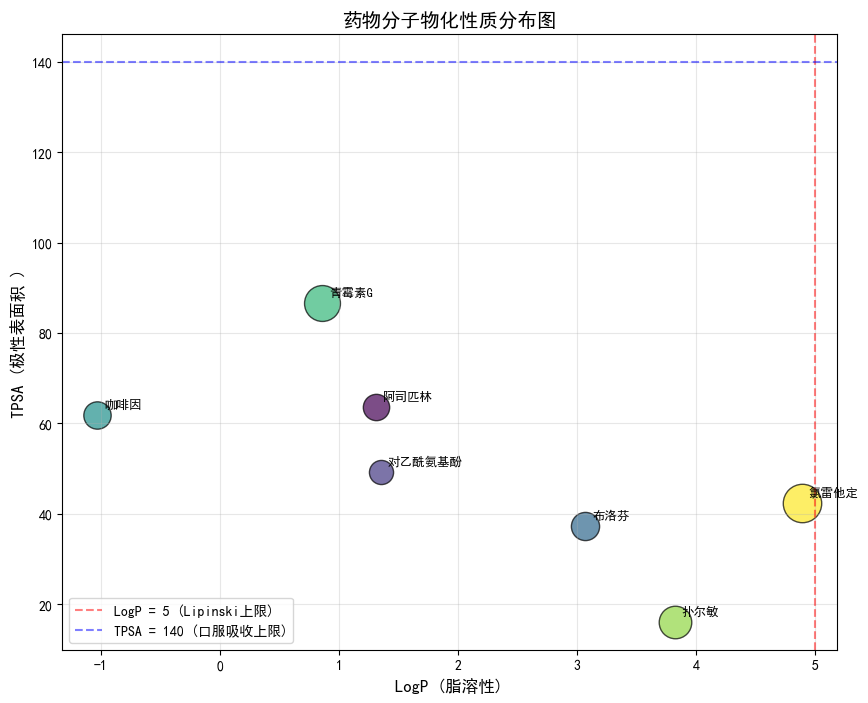

In [15]:
# LogP vs TPSA 散点图
plt.figure(figsize=(10, 8))

# 设置颜色
colors = plt.cm.viridis(np.linspace(0, 1, len(descriptor_df)))

# 绘制散点图
for idx, row in descriptor_df.iterrows():
    plt.scatter(row['LogP'], row['TPSA'], 
                s=row['分子量']*2,  # 点的大小表示分子量
                alpha=0.7, 
                color=colors[idx],
                edgecolor='black',
                linewidth=1)
    plt.annotate(row['药物名称'], 
                (row['LogP'], row['TPSA']), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9)

# 添加参考线
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='LogP = 5 (Lipinski上限)')
plt.axhline(y=140, color='blue', linestyle='--', alpha=0.5, label='TPSA = 140 (口服吸收上限)')

plt.xlabel('LogP (脂溶性)', fontsize=12)
plt.ylabel('TPSA (极性表面积 )', fontsize=12)
plt.title('药物分子物化性质分布图', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 3.5 Lipinski规则批量评估

In [16]:
# 批量进行Lipinski五规则评估
def batch_lipinski_evaluation(df):
    """批量评估Lipinski规则并生成报告"""
    
    # 创建评估结果列
    df['MW_通过'] = df['分子量'] <= 500
    df['LogP_通过'] = df['LogP'] <= 5
    df['HBD_通过'] = df['氢键供体'] <= 5
    df['HBA_通过'] = df['氢键受体'] <= 10
    df['RotBonds_通过'] = df['可旋转键'] <= 10
    
    # 计算总分
    lipinski_columns = ['MW_通过', 'LogP_通过', 'HBD_通过', 'HBA_通过', 'RotBonds_通过']
    df['Lipinski评分'] = df[lipinski_columns].sum(axis=1)
    
    # 评级
    def assign_rating(score):
        if score == 5:
            return '优秀 🌟'
        elif score >= 4:
            return '良好 ✅'
        elif score >= 3:
            return '一般 ⚠️'
        else:
            return '较差 ❌'
    
    df['类药性评级'] = df['Lipinski评分'].apply(assign_rating)
    
    # 生成简洁报告
    report = df[['药物名称', '分子量', 'LogP', 'Lipinski评分', '类药性评级']]
    
    return report

# 执行评估
lipinski_report = batch_lipinski_evaluation(descriptor_df.copy())
print("\n📋 Lipinski五规则批量评估报告:")
print("="*60)
print(lipinski_report.to_string(index=False))


📋 Lipinski五规则批量评估报告:
  药物名称    分子量  LogP  Lipinski评分 类药性评级
  阿司匹林 180.16  1.31           5  优秀 🌟
对乙酰氨基酚 151.16  1.35           5  优秀 🌟
   布洛芬 206.28  3.07           5  优秀 🌟
   咖啡因 194.19 -1.03           5  优秀 🌟
  青霉素G 334.40  0.86           5  优秀 🌟
   扑尔敏 274.80  3.82           5  优秀 🌟
  氯雷他定 382.89  4.89           5  优秀 🌟


### 第四部分：分子指纹与相似性
#### 4.1 Morgan指纹（ECFP）

In [17]:
# 计算Morgan指纹（使用新API以避免废弃警告）
print("🔍 分子指纹计算与相似性分析：")
print("="*50)

# 创建Morgan指纹生成器
from rdkit.Chem import rdFingerprintGenerator

# 使用新的指纹生成器API
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 生成指纹
aspirin_morgan = fpgen.GetFingerprint(aspirin)
caffeine_morgan = fpgen.GetFingerprint(caffeine)

# 查看指纹信息
print(f"Morgan指纹长度: {aspirin_morgan.GetNumBits()} bits")
print(f"阿司匹林激活位数: {aspirin_morgan.GetNumOnBits()}")
print(f"咖啡因激活位数: {caffeine_morgan.GetNumOnBits()}")

# 计算Tanimoto相似性
similarity = DataStructs.TanimotoSimilarity(aspirin_morgan, caffeine_morgan)
print(f"\n阿司匹林与咖啡因的Tanimoto相似性: {similarity:.3f}")

🔍 分子指纹计算与相似性分析：
Morgan指纹长度: 2048 bits
阿司匹林激活位数: 24
咖啡因激活位数: 25

阿司匹林与咖啡因的Tanimoto相似性: 0.089


#### 4.2 MACCS指纹

In [18]:
# 生成MACCS指纹
aspirin_maccs = MACCSkeys.GenMACCSKeys(aspirin)
caffeine_maccs = MACCSkeys.GenMACCSKeys(caffeine)

print(f"\nMACCS指纹信息:")
print(f"  指纹长度: {aspirin_maccs.GetNumBits()} bits (固定)")
print(f"  阿司匹林激活位: {aspirin_maccs.GetNumOnBits()}")
print(f"  咖啡因激活位: {caffeine_maccs.GetNumOnBits()}")

# MACCS相似性
maccs_similarity = DataStructs.TanimotoSimilarity(aspirin_maccs, caffeine_maccs)
print(f"  MACCS相似性: {maccs_similarity:.3f}")


MACCS指纹信息:
  指纹长度: 167 bits (固定)
  阿司匹林激活位: 21
  咖啡因激活位: 46
  MACCS相似性: 0.264


#### 4.3 分子相似性矩阵

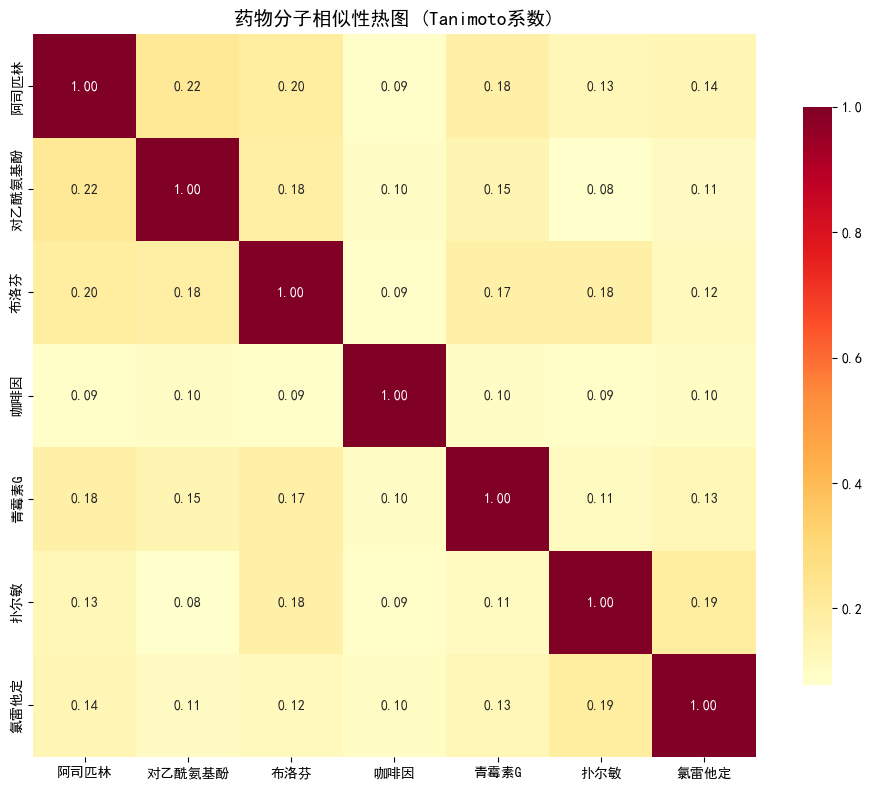

In [19]:
# 计算所有药物之间的相似性矩阵
def calculate_similarity_matrix(smiles_dict):
    """计算分子相似性矩阵（使用新API）"""
    names = list(smiles_dict.keys())
    n = len(names)
    similarity_matrix = np.zeros((n, n))
    
    # 创建指纹生成器
    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    
    # 生成所有分子的指纹
    fingerprints = []
    for smiles in smiles_dict.values():
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            fp = fpgen.GetFingerprint(mol)
            fingerprints.append(fp)
    
    # 计算两两相似性
    for i in range(n):
        for j in range(n):
            if i <= j:
                sim = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
                similarity_matrix[i, j] = sim
                similarity_matrix[j, i] = sim
    
    return pd.DataFrame(similarity_matrix, index=names, columns=names)

# 计算相似性矩阵
sim_matrix = calculate_similarity_matrix(drug_database)

# 可视化相似性矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd', 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('药物分子相似性热图 (Tanimoto系数)', fontsize=14)
plt.tight_layout()
plt.show()

### 第五部分：PAINS过滤器
#### 5.1 PAINS化合物检测

In [20]:
# 创建PAINS过滤器
print("\n⚠️  PAINS (泛检测干扰化合物) 筛选：")
print("="*50)

# 初始化PAINS过滤器
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
filter_catalog = FilterCatalog.FilterCatalog(params)

# 检测函数
def check_pains(mol, name):
    """检查分子是否包含PAINS子结构"""
    if filter_catalog.HasMatch(mol):
        matches = filter_catalog.GetMatches(mol)
        print(f"❌ {name} 包含PAINS子结构:")
        for match in matches:
            print(f"   - {match.GetDescription()}")
        return False
    else:
        print(f"✅ {name} 通过PAINS筛选")
        return True

# 检测所有药物
print("检测常见药物中的PAINS结构：")
for name, smiles in drug_database.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        check_pains(mol, name)
        print()


⚠️  PAINS (泛检测干扰化合物) 筛选：
检测常见药物中的PAINS结构：
✅ 阿司匹林 通过PAINS筛选

✅ 对乙酰氨基酚 通过PAINS筛选

✅ 布洛芬 通过PAINS筛选

✅ 咖啡因 通过PAINS筛选

✅ 青霉素G 通过PAINS筛选

✅ 扑尔敏 通过PAINS筛选

✅ 氯雷他定 通过PAINS筛选



### 第六部分：综合练习
#### 6.1 练习1：基础操作


📝 分析维生素C

🎨 维生素C分子结构:


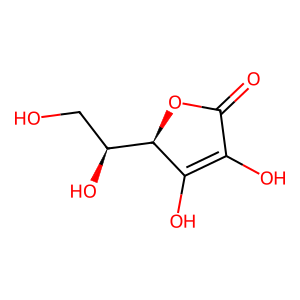


📊 基本信息:
  分子式: C6H8O6
  原子数: 12
  键数: 12
  环数: 1

🔬 物化性质:
  分子量: 176.12 g/mol
  LogP: -1.41
  TPSA: 107.22 Ų
  氢键供体: 4
  氢键受体: 6


In [21]:
print("\n📝 分析维生素C")
print("="*50)

# 1. 从SMILES创建维生素C分子对象
vitamin_c_smiles = "C([C@@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O"
vitamin_c = Chem.MolFromSmiles(vitamin_c_smiles)

# 2. 可视化分子结构
print("\n🎨 维生素C分子结构:")
img = Draw.MolToImage(vitamin_c, size=(300, 300))
display(img)

# 3. 计算基本信息
print("\n📊 基本信息:")
print(f"  分子式: {rdMolDescriptors.CalcMolFormula(vitamin_c)}")
print(f"  原子数: {vitamin_c.GetNumAtoms()}")
print(f"  键数: {vitamin_c.GetNumBonds()}")
print(f"  环数: {vitamin_c.GetRingInfo().NumRings()}")

# 4. 计算关键描述符
print("\n🔬 物化性质:")
mw = Descriptors.MolWt(vitamin_c)
logp = Descriptors.MolLogP(vitamin_c)
tpsa = Descriptors.TPSA(vitamin_c)
hbd = Descriptors.NumHDonors(vitamin_c)
hba = Descriptors.NumHAcceptors(vitamin_c)

print(f"  分子量: {mw:.2f} g/mol")
print(f"  LogP: {logp:.2f}")
print(f"  TPSA: {tpsa:.2f} Ų")
print(f"  氢键供体: {hbd}")
print(f"  氢键受体: {hba}")


#### 6.2 练习2：分子相似性分析


📝 比较咖啡因与茶碱的相似性


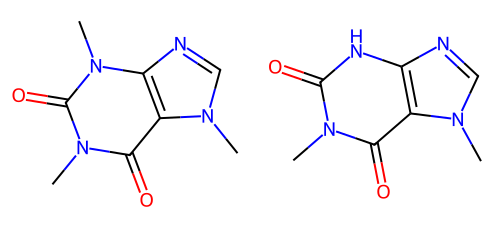


不同指纹方法的相似性比较：
  Morgan指纹 (radius=2): 0.486
  MACCS指纹: 0.957


In [22]:
print("\n📝 比较咖啡因与茶碱的相似性")
print("="*50)

# 茶碱SMILES
theophylline_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2)C"
theophylline = Chem.MolFromSmiles(theophylline_smiles)

# 显示两个分子
img = Draw.MolsToGridImage([caffeine, theophylline], 
                          molsPerRow=2, 
                          subImgSize=(250, 250),
                          legends=['咖啡因', '茶碱'])
display(img)

# 计算各种指纹的相似性
print("\n不同指纹方法的相似性比较：")

# Morgan指纹
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
morgan_sim = DataStructs.TanimotoSimilarity(
    fpgen.GetFingerprint(caffeine),
    fpgen.GetFingerprint(theophylline)
)

# MACCS指纹
maccs_sim = DataStructs.TanimotoSimilarity(
    MACCSkeys.GenMACCSKeys(caffeine),
    MACCSkeys.GenMACCSKeys(theophylline)
)

print(f"  Morgan指纹 (radius=2): {morgan_sim:.3f}")
print(f"  MACCS指纹: {maccs_sim:.3f}")



#### 6.3 练习3：批量筛选类药分子

In [23]:
print("\n📝 从化合物库中筛选类药分子")
print("="*50)

# 模拟化合物库
compound_library = {
    '化合物1': 'CC(=O)Nc1ccc(O)cc1',  # 对乙酰氨基酚
    '化合物2': 'CCCCCCCCCCCCCCCC',  # 十六烷
    '化合物3': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',  # 布洛芬
    '化合物4': 'O=C(O)CCCCCCCCCCCCCCC',  # 棕榈酸
    '化合物5': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',  # 咖啡因
}

# 筛选函数
def screen_compounds(compound_dict, lipinski_threshold=4):
    """筛选符合类药性的化合物"""
    results = []
    
    for name, smiles in compound_dict.items():
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # 计算Lipinski参数
            mw = Descriptors.MolWt(mol)
            logp = Descriptors.MolLogP(mol)
            hbd = Descriptors.NumHDonors(mol)
            hba = Descriptors.NumHAcceptors(mol)
            
            # 评分
            score = sum([
                mw <= 500,
                logp <= 5,
                hbd <= 5,
                hba <= 10
            ])
            
            # PAINS检查
            has_pains = filter_catalog.HasMatch(mol)
            
            results.append({
                '化合物': name,
                'SMILES': smiles,
                '分子量': round(mw, 2),
                'LogP': round(logp, 2),
                'Lipinski评分': f"{score}/4",
                'PAINS': '❌有' if has_pains else '✅无',
                '推荐': '✅' if score >= lipinski_threshold and not has_pains else '❌'
            })
    
    return pd.DataFrame(results)

# 执行筛选
screening_results = screen_compounds(compound_library)
print("筛选结果：")
print(screening_results.to_string(index=False))


📝 从化合物库中筛选类药分子
筛选结果：
 化合物                       SMILES    分子量  LogP Lipinski评分 PAINS 推荐
化合物1           CC(=O)Nc1ccc(O)cc1 151.16  1.35        4/4    ✅无  ✅
化合物2             CCCCCCCCCCCCCCCC 226.45  6.49        3/4    ✅无  ❌
化合物3   CC(C)Cc1ccc(C(C)C(=O)O)cc1 206.28  3.07        4/4    ✅无  ✅
化合物4        O=C(O)CCCCCCCCCCCCCCC 256.43  5.55        3/4    ✅无  ❌
化合物5 CN1C=NC2=C1C(=O)N(C(=O)N2C)C 194.19 -1.03        4/4    ✅无  ✅
